In [16]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\sagar\OneDrive\Desktop\Diabetes_Prediction_Project\data\diabetes.csv"
)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.shape

(769, 9)

In [18]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


In [20]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.847854,120.894668,69.171651,20.542263,79.832250,31.996489,0.471802,33.227568,0.349805
std,3.368280,31.951796,19.430074,15.942641,115.172535,7.879772,0.331119,11.758373,0.477219
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.374000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [22]:
import numpy as np
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columns_to_fix] = df[columns_to_fix].replace(0, np.nan)

In [23]:
df[columns_to_fix] = df[columns_to_fix].fillna(df[columns_to_fix].median())

In [24]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [25]:
df["Outcome"].value_counts()

Outcome
0    500
1    269
Name: count, dtype: int64

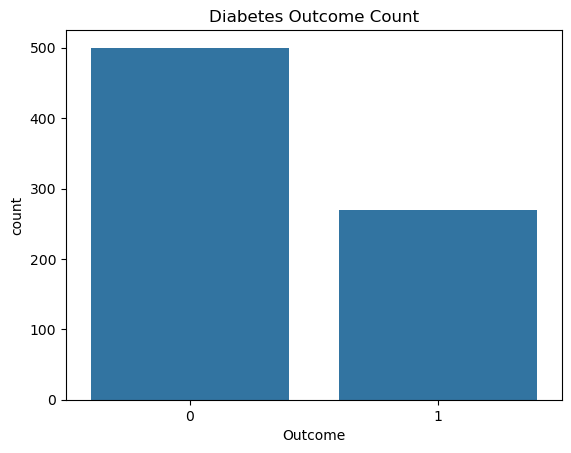

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Count")
plt.show()

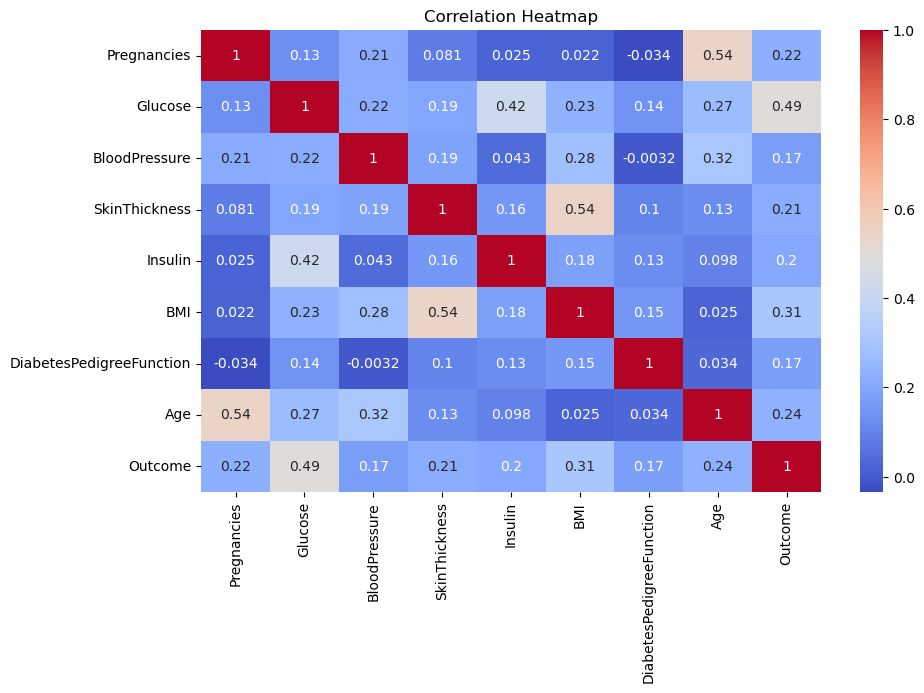

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

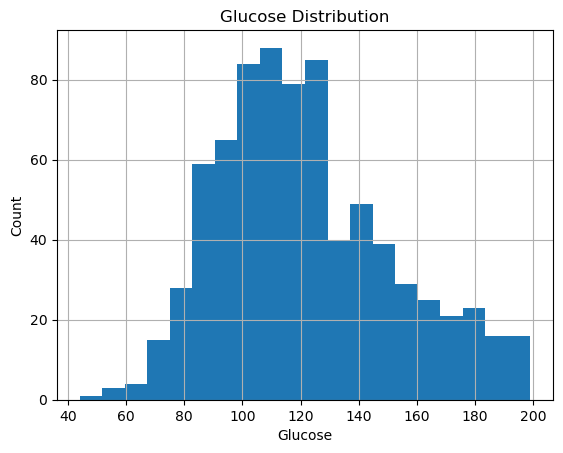

In [28]:
df["Glucose"].hist(bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Count")
plt.show()

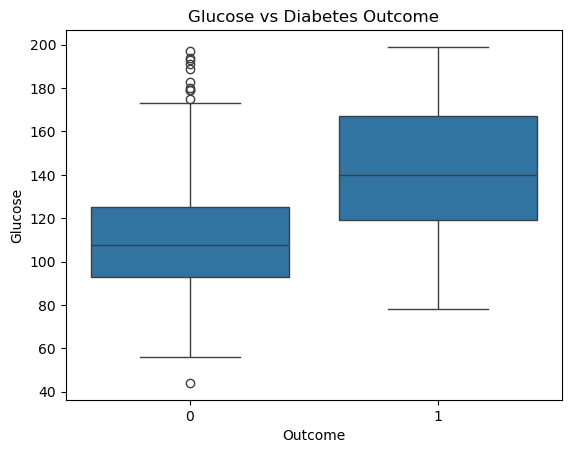

In [29]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

In [30]:
X = df.drop("Outcome", axis=1)   # All input features
y = df["Outcome"]               # Target column


In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [33]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)


LogisticRegression()

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lda_pred = lda_model.predict(X_test_scaled)


In [35]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("LDA Accuracy:", accuracy_score(y_test, lda_pred))


Logistic Regression Accuracy: 0.7792207792207793
LDA Accuracy: 0.7597402597402597


In [36]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n")
print(classification_report(y_test, lr_pred))
print("\nLDA Report:\n")
print(classification_report(y_test, lda_pred))


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.69      0.67      0.68        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154


LDA Report:

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       100
           1       0.66      0.65      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



In [37]:
from sklearn.metrics import confusion_matrix
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("\nLDA Confusion Matrix:\n", confusion_matrix(y_test, lda_pred))

Logistic Regression Confusion Matrix:
 [[84 16]
 [18 36]]

LDA Confusion Matrix:
 [[82 18]
 [19 35]]


In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Probability of class 1 (Diabetes)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lda_probs = lda_model.predict_proba(X_test_scaled)[:, 1]

In [39]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lda_fpr, lda_tpr, _ = roc_curve(y_test, lda_probs)

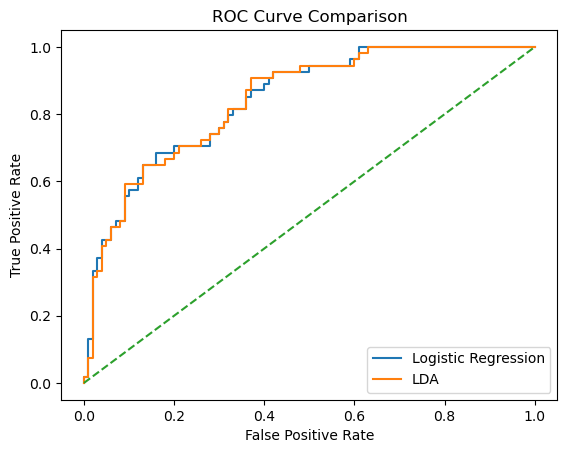

In [40]:
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(lda_fpr, lda_tpr, label="LDA")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [41]:
print("Logistic Regression AUC:", roc_auc_score(y_test, lr_probs))
print("LDA AUC:", roc_auc_score(y_test, lda_probs))

Logistic Regression AUC: 0.8411111111111111
LDA AUC: 0.8407407407407408


In [42]:
feature_names = X.columns
feature_names

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [43]:
importance = lr_model.coef_[0]
importance 

array([ 0.33070055,  1.10184755, -0.07719587,  0.03302738, -0.16112923,
        0.67128286,  0.20516262,  0.30300966])

In [44]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": importance
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)
feature_importance


,Feature,Coefficient
1,Glucose,1.101848
5,BMI,0.671283
0,Pregnancies,0.330701
7,Age,0.303010
6,DiabetesPedigreeFunction,0.205163
3,SkinThickness,0.033027
2,BloodPressure,-0.077196
4,Insulin,-0.161129


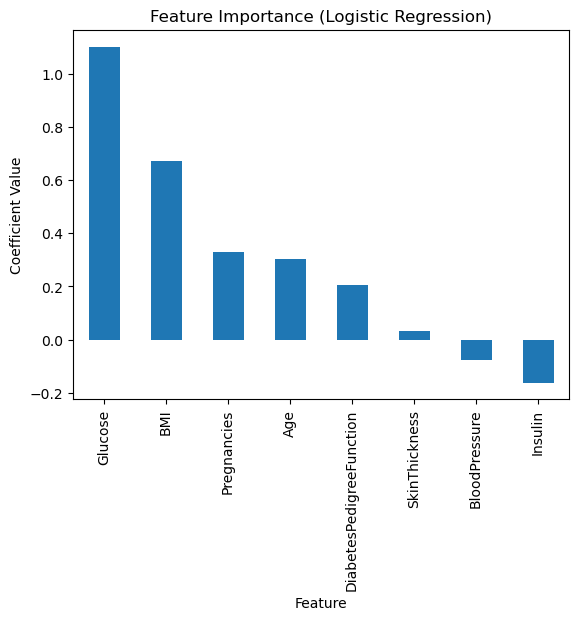

In [45]:
import matplotlib.pyplot as plt

feature_importance.set_index("Feature").plot(kind="bar", legend=False)
plt.title("Feature Importance (Logistic Regression)")
plt.ylabel("Coefficient Value")
plt.show()

In [46]:
import os
os.getcwd()


'C:\\Users\\sagar\\OneDrive\\Desktop\\Diabetes_Prediction_Project\\notebooks'

In [47]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr_model, "models/lr_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("✅ Model and scaler saved in models folder")


✅ Model and scaler saved in models folder


In [48]:
print(locals().keys())


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'json', 'getpass', 'hashlib', 'import_pandas_safely', '__pandas', 'is_data_frame', 'dataframe_columns', 'dtypes_str', 'dataframe_hash', 'get_dataframes', '_2', '_i3', 'os', '_3', '_i4', '_4', '_i5', '_5', '_i6', '_6', '_i7', '_7', '_i8', '_8', '_i9', '_i10', '_10', '_i11', '_i12', '_12', '_i13', 'joblib', '_i14', '_14', '_i15', '_15', '_i16', 'pd', 'df', '_16', '_i17', '_17', '_i18', '_18', '_i19', '_i20', '_20', '_i21', '_21', '_i22', 'np', 'columns_to_fix', '_i23', '_i24', '_24', '_i25', '_25', '_i26', 'sns', 'plt', '_i27', '_i28', '_i29', '_i30', 'X', 'y', '_i31', 'train_test_split', 'X_train', 'X_test', 'y_train', 'y_test', '_i32', 'StandardScaler', 'scaler', 'X_train_scaled', 'X_test_scaled', '_i33', 'LogisticRegression', 'lr_model', '_33

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [51]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)


LogisticRegression()

In [52]:
lr_model


LogisticRegression()

In [53]:
scaler


StandardScaler()

In [54]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr_model, "models/lr_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and scaler saved successfully")


Model and scaler saved successfully
